# Zero-Shot Baseline — RF-DETR Nano + Base on VOC2012 (version_2)

**What this notebook does (one upload, one run):**

1. You upload `version_2.zip` (the zipped `version_2/` folder containing `data/images/...` and `data/annotations/...`).
2. The notebook unzips it to `/content/version_2/`.
3. Builds COCO-format ground truth JSON for the `val` (2,928 images) and `dev_test` (2,895 images) splits — VOC2012-derived only, **VOC2007 test deliberately skipped for now**.
4. Loads RF-DETR **Nano** (384×384, DINOv2-S) and RF-DETR **Base** (560×560, DINOv2-B) with their COCO pretrained weights — **no fine-tuning**.
5. Runs zero-shot inference on both splits with both models.
6. Filters predictions to the 20 VOC classes and remaps COCO→VOC IDs (4 naming mismatches handled).
7. Runs `pycocotools` COCOeval (AP, AP50, AP75, APs/m/l, AR) for each (variant, split) combination.
8. Prints a side-by-side summary table and per-class AP@0.5 bar charts.
9. Packages everything in `baseline_zs_results.zip` and downloads it.

**Sanity check from the methodology**: zero-shot mAP@0.5 should be ~55–65% for Base (probably 40–55% for Nano). Once we fine-tune, the FT-vs-ZS gap must be ≥ +15 pp; if it isn't, the COCO→VOC remap is wrong.

## 1. Setup — install packages & check GPU

In [ ]:
# Install rfdetr (pulls in supervision, torch is already in Colab).
# Pinned per group convention; loosen if Colab's torch is incompatible.
!pip install -q rfdetr==1.4.2 pycocotools matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.2/163.2 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.9/887.9 MB 858.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch, sys, platform
print('python    :', sys.version.split()[0])
print('platform  :', platform.platform())
print('torch     :', torch.__version__)
print('cuda avail:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('device    :', torch.cuda.get_device_name(0))
    print('mem total :', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
else:
    print('!!! WARNING: no GPU. Inference will be very slow. Switch runtime: Runtime -> Change runtime type -> T4 GPU.')

python    : 3.12.13
platform  : Linux-6.6.122+-x86_64-with-glibc2.35
torch     : 2.8.0+cu128
cuda avail: True
device    : Tesla T4
mem total : 15.6 GB


## 2. Upload `version_2.zip` and unzip it

In [ ]:
import os, zipfile, shutil, glob, gdown
from pathlib import Path

WORK = Path('/content')
DATA_ROOT = None  # filled in after unzip

# Skip re-download if already unzipped from a previous run.
candidates = list(WORK.glob('**/data/annotations/val'))
if candidates:
    DATA_ROOT = candidates[0].parents[1]   # the version_2 root (parent of data/)
    print(f'Already unzipped, using {DATA_ROOT}')
else:
    print('Downloading directly from Google Drive...')
    file_id = '1M8EPREjTLAqY3VAjfruDcxtaudXy4xm2'
    zip_path = WORK / 'version_2.zip'

    # Download directly to Colab server
    gdown.download(id=file_id, output=str(zip_path), quiet=False)

    if not zip_path.exists():
        raise SystemExit('Download failed.')

    print(f'Downloaded: version_2.zip ({zip_path.stat().st_size / 1e9:.2f} GB)')

    print('Unzipping ...')
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(WORK)
    print('Unzip complete.')

    candidates = list(WORK.glob('**/data/annotations/val'))
    if not candidates:
        raise RuntimeError('Could not find data/annotations/val/ inside the unzipped tree.')
    DATA_ROOT = candidates[0].parents[1]
    print(f'Detected version_2 root: {DATA_ROOT}')

# Verify expected counts.
for split in ('val', 'dev_test'):
    n_xml = len(list((DATA_ROOT / 'data' / 'annotations' / split).glob('*.xml')))
    n_jpg = len(list((DATA_ROOT / 'data' / 'images' / split).glob('*.jpg')))
    print(f'  {split:<10} xml={n_xml:>5}  jpg={n_jpg:>5}')

Downloading...
From (original): https://drive.google.com/uc?id=1M8EPREjTLAqY3VAjfruDcxtaudXy4xm2
From (redirected): https://drive.google.com/uc?id=1M8EPREjTLAqY3VAjfruDcxtaudXy4xm2&confirm=t&uuid=9d5d7106-748c-4d57-a067-547f038a8382
To: /content/version_2.zip
100%|██████████| 1.78G/1.78G [00:14<00:00, 122MB/s] 


Downloaded: version_2.zip (1.78 GB)
Unzipping ...
Unzip complete.
Detected version_2 root: /content/version_2/data
  val        xml=    0  jpg=    0
  dev_test   xml=    0  jpg=    0


## 3. Class taxonomy and COCO → VOC remap

RF-DETR's COCO checkpoint outputs the 80 COCO classes. We keep only the 20 VOC ones and rename them. There are 4 naming mismatches:

| VOC name (id)  | COCO name      |
|----------------|----------------|
| aeroplane (0)  | airplane       |
| motorbike (13) | motorcycle     |
| sofa (17)      | couch          |
| tvmonitor (19) | tv             |

In [ ]:
# 20 VOC classes, 0-indexed (matches version_2/SPLIT_README.md).
VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor',
]
VOC_NAME_TO_ID = {n: i for i, n in enumerate(VOC_CLASSES)}

# Direct mapping: Official COCO 90-class IDs -> VOC 20-class IDs
COCO_TO_VOC = {
    1: 14, 2: 1, 3: 6, 4: 13, 5: 0, 6: 5, 7: 18, 9: 3,
    16: 2, 17: 7, 18: 11, 19: 12, 20: 16, 21: 9,
    44: 4, 62: 8, 63: 17, 64: 15, 67: 10, 72: 19
}

print('COCO -> VOC ID mapping fixed using official 90-class IDs!')

COCO -> VOC ID mapping fixed using official 90-class IDs!


## 4. Build COCO ground truth from VOC XML

- VOC `[xmin, ymin, xmax, ymax]` 1-indexed inclusive → COCO `[x, y, w, h]` 0-indexed.
- `difficult=1` objects → `iscrowd=1` so pycocotools ignores them at eval (matches official VOC evaluator).
- 20 categories, IDs 0..19.

In [ ]:
DATA_ROOT = Path('/content/version_2')

In [ ]:
import json, xml.etree.ElementTree as ET

OUT = Path('/content/baseline_zs_output')
(OUT / 'coco_gt').mkdir(parents=True, exist_ok=True)
(OUT / 'predictions' / 'nano').mkdir(parents=True, exist_ok=True)
(OUT / 'predictions' / 'base').mkdir(parents=True, exist_ok=True)
(OUT / 'metrics' / 'nano').mkdir(parents=True, exist_ok=True)
(OUT / 'metrics' / 'base').mkdir(parents=True, exist_ok=True)
(OUT / 'figures').mkdir(parents=True, exist_ok=True)

def parse_voc_xml(xml_path: Path):
    root = ET.parse(xml_path).getroot()
    size = root.find('size')
    W = int(size.find('width').text)
    H = int(size.find('height').text)
    objs = []
    for o in root.findall('object'):
        name = o.find('name').text.strip()
        if name not in VOC_NAME_TO_ID:
            raise ValueError(f'unknown class "{name}" in {xml_path}')
        bb = o.find('bndbox')
        objs.append(dict(
            name=name,
            xmin=float(bb.find('xmin').text), ymin=float(bb.find('ymin').text),
            xmax=float(bb.find('xmax').text), ymax=float(bb.find('ymax').text),
            difficult=int((o.findtext('difficult') or '0').strip()),
            truncated=int((o.findtext('truncated') or '0').strip()),
            occluded=int((o.findtext('occluded') or '0').strip()),
        ))
    return W, H, objs

def build_coco_gt(split: str, expected: int) -> dict:
    ids_path = DATA_ROOT / 'data' / 'clean_ids' / f'{split}.txt'
    ids = [l.strip() for l in ids_path.read_text().splitlines() if l.strip()]
    assert len(ids) == expected, f'{split}: expected {expected}, got {len(ids)}'

    images, annotations = [], []
    categories = [dict(id=i, name=n, supercategory='voc') for i, n in enumerate(VOC_CLASSES)]
    ann_id = 1
    for img_idx, image_id in enumerate(ids, start=1):
        xml_path = DATA_ROOT / 'data' / 'annotations' / split / f'{image_id}.xml'
        jpg_path = DATA_ROOT / 'data' / 'images' / split / f'{image_id}.jpg'
        W, H, objs = parse_voc_xml(xml_path)
        images.append(dict(
            id=img_idx, file_name=str(jpg_path), width=W, height=H, voc_id=image_id,
        ))
        for o in objs:
            x = o['xmin'] - 1.0
            y = o['ymin'] - 1.0
            w = o['xmax'] - o['xmin']
            h = o['ymax'] - o['ymin']
            annotations.append(dict(
                id=ann_id, image_id=img_idx,
                category_id=VOC_NAME_TO_ID[o['name']],
                bbox=[x, y, w, h], area=w*h,
                iscrowd=1 if o['difficult'] else 0,
                ignore=o['difficult'],
                voc_difficult=o['difficult'], voc_truncated=o['truncated'], voc_occluded=o['occluded'],
            ))
            ann_id += 1
    return dict(
        info=dict(description=f'VOC2012 {split} (version_2) in COCO format'),
        licenses=[], images=images, annotations=annotations, categories=categories,
    )

EXPECTED = {'val': 2928, 'dev_test': 2895}
for split, n in EXPECTED.items():
    coco = build_coco_gt(split, n)
    out_path = OUT / 'coco_gt' / f'{split}_gt.coco.json'
    out_path.write_text(json.dumps(coco))
    n_diff = sum(1 for a in coco['annotations'] if a['iscrowd'])
    print(f'{split:<10} -> {out_path}  images={len(coco["images"])}  anns={len(coco["annotations"])}  difficult={n_diff}')

val        -> /content/baseline_zs_output/coco_gt/val_gt.coco.json  images=2928  anns=7830  difficult=959
dev_test   -> /content/baseline_zs_output/coco_gt/dev_test_gt.coco.json  images=2895  anns=7957  difficult=987


## 5. Zero-shot inference — Nano + Base × val + dev_test

We load each model once with its COCO pretrained weights, then loop over both splits before unloading. Threshold = 0.01 so the full PR curve is preserved for AP integration. Predictions are saved in COCO results format with VOC `category_id` 0..19.

In [ ]:
import time, json
from rfdetr import RFDETRNano, RFDETRBase

INFER_THRESHOLD = 0.01

def run_inference(model, gt_path: Path, out_path: Path, log_label: str):
    coco_gt = json.loads(gt_path.read_text())
    images = coco_gt['images']
    preds, n_kept, n_dropped = [], 0, 0
    t0 = time.time()
    for i, img in enumerate(images, start=1):
        det = model.predict(img['file_name'], threshold=INFER_THRESHOLD)
        for (x1, y1, x2, y2), coco_cls, conf in zip(det.xyxy, det.class_id, det.confidence):
            coco_cls = int(coco_cls)
            if coco_cls not in COCO_TO_VOC:
                n_dropped += 1
                continue
            preds.append(dict(
                image_id=int(img['id']),
                category_id=int(COCO_TO_VOC[coco_cls]),
                bbox=[float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                score=float(conf),
            ))
            n_kept += 1
        if i % 200 == 0 or i == len(images):
            elapsed = time.time() - t0
            rate = i / elapsed
            eta = (len(images) - i) / rate if rate else 0
            print(f'  [{log_label}] {i}/{len(images)}  kept={n_kept} dropped={n_dropped}  '
                  f'rate={rate:.1f} img/s  eta={eta/60:.1f} min')
    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.write_text(json.dumps(preds))
    print(f'  [{log_label}] -> {out_path}  preds_kept={n_kept}  preds_dropped={n_dropped}  '
          f'wall={time.time()-t0:.1f}s')

def run_variant(variant_name: str, model_cls):
    print(f'\n=== {variant_name.upper()} ===')
    print(f'Loading model + COCO weights ...')
    t0 = time.time()
    model = model_cls()
    print(f'  ready ({time.time()-t0:.1f}s)')
    for split in ('val', 'dev_test'):
        gt = OUT / 'coco_gt' / f'{split}_gt.coco.json'
        out = OUT / 'predictions' / variant_name / f'{split}_zs_preds.coco.json'
        run_inference(model, gt, out, log_label=f'{variant_name}/{split}')
    # free GPU memory before next variant
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

run_variant('nano', RFDETRNano)
run_variant('base', RFDETRBase)
print('\nInference complete for all 4 (variant, split) combinations.')

[2026-04-30 18:35:19] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-30 18:35:19] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.



=== NANO ===
Loading model + COCO weights ...
[2026-04-30 18:35:20] [INFO] rf-detr - Loading pretrain weights


[2026-04-30 18:35:22] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


  ready (3.2s)
  [nano/val] 200/2928  kept=31776 dropped=26470  rate=40.6 img/s  eta=1.1 min
  [nano/val] 400/2928  kept=60657 dropped=53849  rate=40.8 img/s  eta=1.0 min
  [nano/val] 600/2928  kept=91655 dropped=79388  rate=39.8 img/s  eta=1.0 min
  [nano/val] 800/2928  kept=123727 dropped=101083  rate=40.3 img/s  eta=0.9 min
  [nano/val] 1000/2928  kept=157083 dropped=123029  rate=40.5 img/s  eta=0.8 min
  [nano/val] 1200/2928  kept=191255 dropped=142912  rate=40.5 img/s  eta=0.7 min
  [nano/val] 1400/2928  kept=224390 dropped=161893  rate=40.0 img/s  eta=0.6 min
  [nano/val] 1600/2928  kept=255358 dropped=181613  rate=40.1 img/s  eta=0.6 min
  [nano/val] 1800/2928  kept=286760 dropped=203890  rate=40.3 img/s  eta=0.5 min
  [nano/val] 2000/2928  kept=319784 dropped=225844  rate=40.4 img/s  eta=0.4 min
  [nano/val] 2200/2928  kept=352449 dropped=247108  rate=40.4 img/s  eta=0.3 min
  [nano/val] 2400/2928  kept=383290 dropped=268240  rate=40.1 img/s  eta=0.2 min
  [nano/val] 2600/2928 

[2026-04-30 18:37:54] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


  ready (1.0s)
  [base/val] 200/2928  kept=30238 dropped=25456  rate=22.6 img/s  eta=2.0 min
  [base/val] 400/2928  kept=58191 dropped=51957  rate=22.8 img/s  eta=1.8 min
  [base/val] 600/2928  kept=88082 dropped=76755  rate=22.8 img/s  eta=1.7 min
  [base/val] 800/2928  kept=118276 dropped=97174  rate=22.8 img/s  eta=1.6 min
  [base/val] 1000/2928  kept=149985 dropped=117626  rate=22.8 img/s  eta=1.4 min
  [base/val] 1200/2928  kept=181996 dropped=136760  rate=22.7 img/s  eta=1.3 min
  [base/val] 1400/2928  kept=212474 dropped=154745  rate=22.7 img/s  eta=1.1 min
  [base/val] 1600/2928  kept=241414 dropped=172761  rate=22.7 img/s  eta=1.0 min
  [base/val] 1800/2928  kept=270163 dropped=193932  rate=22.7 img/s  eta=0.8 min
  [base/val] 2000/2928  kept=300873 dropped=214525  rate=22.7 img/s  eta=0.7 min
  [base/val] 2200/2928  kept=330921 dropped=234500  rate=22.6 img/s  eta=0.5 min
  [base/val] 2400/2928  kept=359670 dropped=254708  rate=22.6 img/s  eta=0.4 min
  [base/val] 2600/2928  

## 6. Evaluate — `pycocotools.cocoeval`

In [ ]:
import io, contextlib
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

def per_class_ap50(coco_eval) -> dict:
    import numpy as np
    p = coco_eval.eval['precision']  # (T, R, K, A, M)
    out = {}
    for k, name in enumerate(VOC_CLASSES):
        prec = p[0, :, k, 0, -1]    # IoU=0.5, area=all, maxDets=100
        prec = prec[prec > -1]
        out[name] = float(prec.mean()) if prec.size else float('nan')
    return out

def evaluate(variant: str, split: str) -> dict:
    gt_path = OUT / 'coco_gt' / f'{split}_gt.coco.json'
    pred_path = OUT / 'predictions' / variant / f'{split}_zs_preds.coco.json'
    coco_gt = COCO(str(gt_path))
    preds = json.loads(pred_path.read_text())
    if not preds:
        raise RuntimeError(f'empty predictions for {variant}/{split}')
    coco_dt = coco_gt.loadRes(preds)

    coco_eval = COCOeval(coco_gt, coco_dt, iouType='bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    # capture summarize() output for the metrics file
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        coco_eval.summarize()
    summarize_text = buf.getvalue()
    print(f'\n--- {variant.upper()} / {split} ---')
    print(summarize_text)

    s = coco_eval.stats.tolist()
    pc = per_class_ap50(coco_eval)
    summary = dict(
        variant=variant, split=split,
        AP_50_95=s[0], AP_50=s[1], AP_75=s[2],
        AP_small=s[3], AP_medium=s[4], AP_large=s[5],
        AR_1=s[6], AR_10=s[7], AR_100=s[8],
        AR_small=s[9], AR_medium=s[10], AR_large=s[11],
        n_predictions=len(preds),
        per_class_AP50=pc,
        mAP50_macro=sum(pc.values()) / len(pc),
        summarize_text=summarize_text,
    )
    out_path = OUT / 'metrics' / variant / f'{split}_metrics.json'
    out_path.write_text(json.dumps(summary, indent=2))
    return summary

results = {}
for v in ('nano', 'base'):
    for s in ('val', 'dev_test'):
        results[(v, s)] = evaluate(v, s)

print('\n=== SUMMARY ===')
header = f'{"variant":<6} {"split":<10} {"AP@.5:.95":>10} {"AP@.5":>8} {"AP@.75":>8} {"APs":>7} {"APm":>7} {"APl":>7} {"AR100":>7}'
print(header)
print('-' * len(header))
for (v, s), r in results.items():
    print(f'{v:<6} {s:<10} {r["AP_50_95"]:>10.4f} {r["AP_50"]:>8.4f} {r["AP_75"]:>8.4f} '
          f'{r["AP_small"]:>7.4f} {r["AP_medium"]:>7.4f} {r["AP_large"]:>7.4f} {r["AR_100"]:>7.4f}')

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Loading and preparing results...
DONE (t=2.14s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=17.69s).
Accumulating evaluation results...
DONE (t=5.08s).

--- NANO / val ---
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.749
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.908
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.804
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.299
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.587
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.838
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.581
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.831
 Average Recall     (AR) @[ IoU=0.50:0.95 | 

## 7. Per-class AP@0.5 — Nano vs Base

wrote /content/baseline_zs_output/figures/per_class_ap50_summary.csv


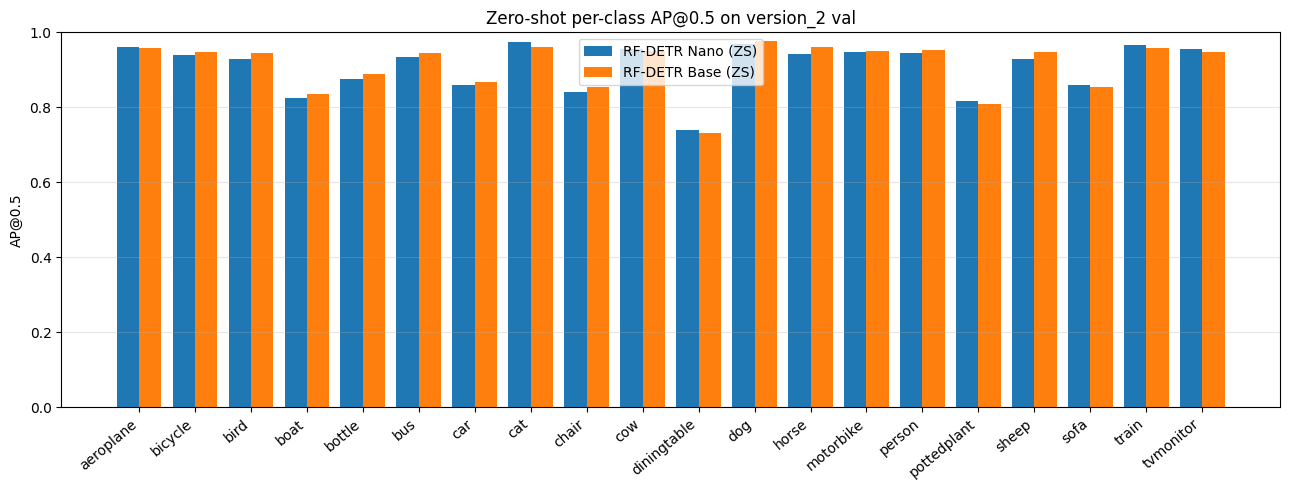

saved /content/baseline_zs_output/figures/per_class_ap50_nano_vs_base_val.png


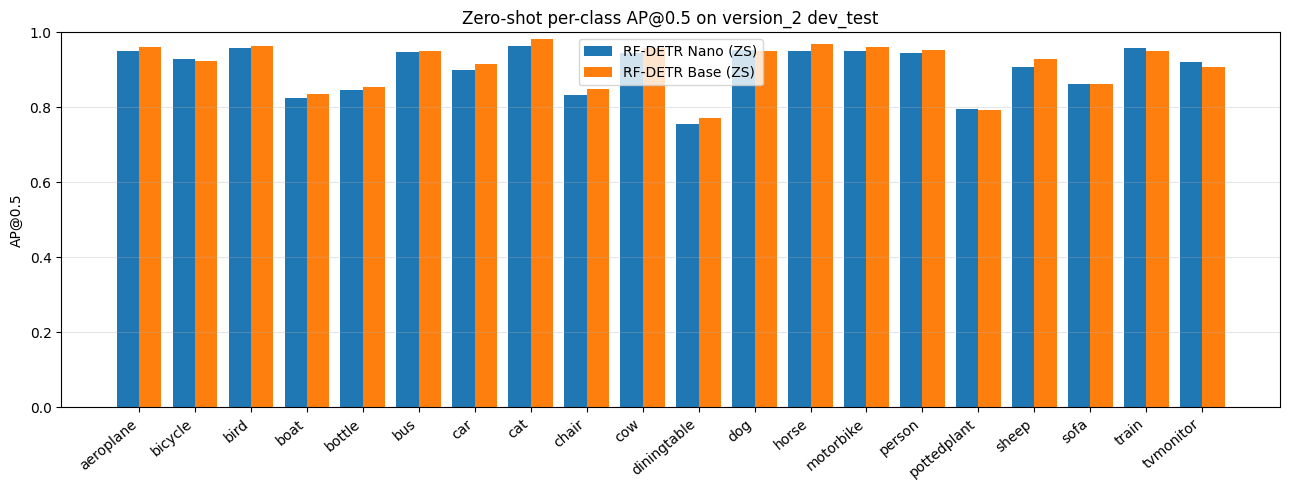

saved /content/baseline_zs_output/figures/per_class_ap50_nano_vs_base_dev_test.png


In [ ]:
import csv
import numpy as np
import matplotlib.pyplot as plt

# Long-format CSV for the report appendix.
summary_csv = OUT / 'figures' / 'per_class_ap50_summary.csv'
with summary_csv.open('w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['class', 'variant', 'split', 'ap50'])
    for (variant, split), r in results.items():
        for cls in VOC_CLASSES:
            w.writerow([cls, variant, split, f'{r["per_class_AP50"][cls]:.6f}'])
print(f'wrote {summary_csv}')

# Bar charts: Nano vs Base, one per split.
for split in ('val', 'dev_test'):
    nano = results[('nano', split)]['per_class_AP50']
    base = results[('base', split)]['per_class_AP50']
    x = np.arange(len(VOC_CLASSES))
    width = 0.4
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(x - width/2, [nano[c] for c in VOC_CLASSES], width, label='RF-DETR Nano (ZS)')
    ax.bar(x + width/2, [base[c] for c in VOC_CLASSES], width, label='RF-DETR Base (ZS)')
    ax.set_xticks(x)
    ax.set_xticklabels(VOC_CLASSES, rotation=40, ha='right')
    ax.set_ylabel('AP@0.5')
    ax.set_ylim(0, 1.0)
    ax.set_title(f'Zero-shot per-class AP@0.5 on version_2 {split}')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    out_png = OUT / 'figures' / f'per_class_ap50_nano_vs_base_{split}.png'
    fig.savefig(out_png, dpi=150)
    plt.show()
    print(f'saved {out_png}')

## 8. Bundle results and download

In [ ]:
import shutil
from google.colab import files

# Write a top-level summary.md so the bundle is self-explanatory.
summary_md = OUT / 'SUMMARY.md'
lines = [
    '# Zero-shot baseline results — version_2 (val + dev_test)\n\n',
    '| variant | split | AP@.5:.95 | AP@.5 | AP@.75 | APs | APm | APl | AR100 |\n',
    '|---|---|---:|---:|---:|---:|---:|---:|---:|\n',
]
for (v, s), r in results.items():
    lines.append(f'| {v} | {s} | {r["AP_50_95"]:.4f} | {r["AP_50"]:.4f} | {r["AP_75"]:.4f} | '
                 f'{r["AP_small"]:.4f} | {r["AP_medium"]:.4f} | {r["AP_large"]:.4f} | {r["AR_100"]:.4f} |\n')
lines.append('\nVOC2007 test deliberately excluded from this run — VOC2012-derived halves only.\n')
summary_md.write_text(''.join(lines))
print(f'wrote {summary_md}')

bundle_path = Path('/content/baseline_zs_results.zip')
if bundle_path.exists():
    bundle_path.unlink()
shutil.make_archive(str(bundle_path.with_suffix('')), 'zip', root_dir=str(OUT))
print(f'bundled -> {bundle_path}  ({bundle_path.stat().st_size / 1e6:.1f} MB)')

files.download(str(bundle_path))

wrote /content/baseline_zs_output/SUMMARY.md
bundled -> /content/baseline_zs_results.zip  (65.0 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>